In [2]:
import pandas as pd

df = pd.read_csv('spotify_millsongdata.csv')

df.head()

,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...


In [3]:
df.columns

Index(['artist', 'song', 'link', 'text'], dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57650 entries, 0 to 57649
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   artist  57650 non-null  object
 1   song    57650 non-null  object
 2   link    57650 non-null  object
 3   text    57650 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [5]:
# Check missing values
df.isnull().sum()

,0
artist,0
song,0
link,0
text,0


In [6]:
# Remove missing values
df = df.dropna()

# Check dataset size
df.shape

(57650, 4)

In [7]:
!pip install textblob

In [8]:
from textblob import TextBlob

# Function to calculate sentiment
def get_sentiment(text):
    analysis = TextBlob(str(text))

    if analysis.sentiment.polarity > 0:
        return "Positive"
    elif analysis.sentiment.polarity < 0:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment analysis
df['Sentiment'] = df['text'].apply(get_sentiment)

# View results
df[['song', 'artist', 'Sentiment']].head()

,song,artist,Sentiment
0,Ahe's My Kind Of Girl,ABBA,Positive
1,"Andante, Andante",ABBA,Positive
2,As Good As New,ABBA,Positive
3,Bang,ABBA,Positive
4,Bang-A-Boomerang,ABBA,Positive


In [9]:
df['Sentiment'].value_counts()

,count
Sentiment,
Positive,42909
Negative,14110
Neutral,631


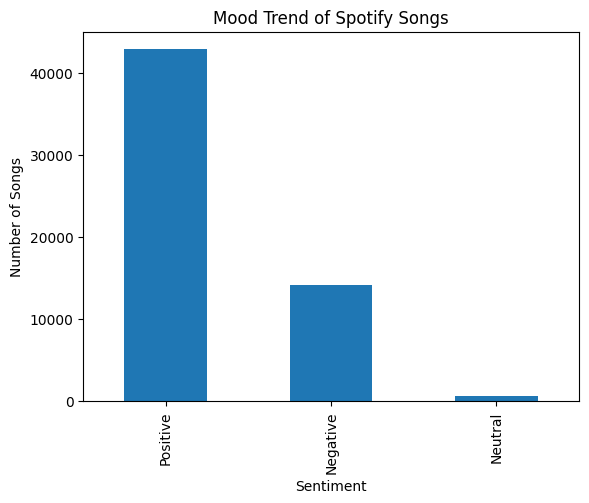

In [10]:
import matplotlib.pyplot as plt

# Count sentiments
sentiment_counts = df['Sentiment'].value_counts()

# Plot graph
sentiment_counts.plot(kind='bar')

plt.title('Mood Trend of Spotify Songs')
plt.xlabel('Sentiment')
plt.ylabel('Number of Songs')

plt.show()

In [11]:
from textblob import TextBlob

# Calculate polarity score
df['Polarity'] = df['text'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

# Top positive songs
top_positive = df[['song', 'artist', 'Polarity']].sort_values(
    by='Polarity',
    ascending=False
)

top_positive.head(10)

,song,artist,Polarity
24166,Three Coins In The Fountain,Andy Williams,1.0
19931,Legalise It,UB40,1.0
46000,The Perfect Drug (Meat Beat Manifesto),Nine Inch Nails,1.0
36155,Eden,Hooverphonic,1.0
15511,That Wonderful Someone,Patsy Cline,1.0
27463,All Together Now,Children,1.0
43363,Goin' Up Yonder - Angel Burgess,Mc Hammer,1.0
6729,Brothers Of The Highway,George Strait,1.0
42092,Real Good Time Together,Lou Reed,1.0
30393,Baby Doll,Doris Day,1.0


In [12]:
# Top negative songs
top_negative = df[['song', 'artist', 'Polarity']].sort_values(
    by='Polarity'
)

top_negative.head(10)

,song,artist,Polarity
10795,I Wanna Be Sedated,Kirsty Maccoll,-1.000000
21655,The King Will Come,Wishbone Ash,-1.000000
44171,Scream!,Misfits,-1.000000
48259,F-Games,Phineas And Ferb,-1.000000
39456,Watching You Without Me,Kate Bush,-1.000000
50688,It Happened Today,Rem,-1.000000
14715,I Wanna Be Sedated,Offspring,-1.000000
54992,The Evil One,Venom,-0.866667
31826,Kind Hearted Woman,Eric Clapton,-0.800000
44181,The Haunting,Misfits,-0.800000


In [13]:
!pip install wordcloud

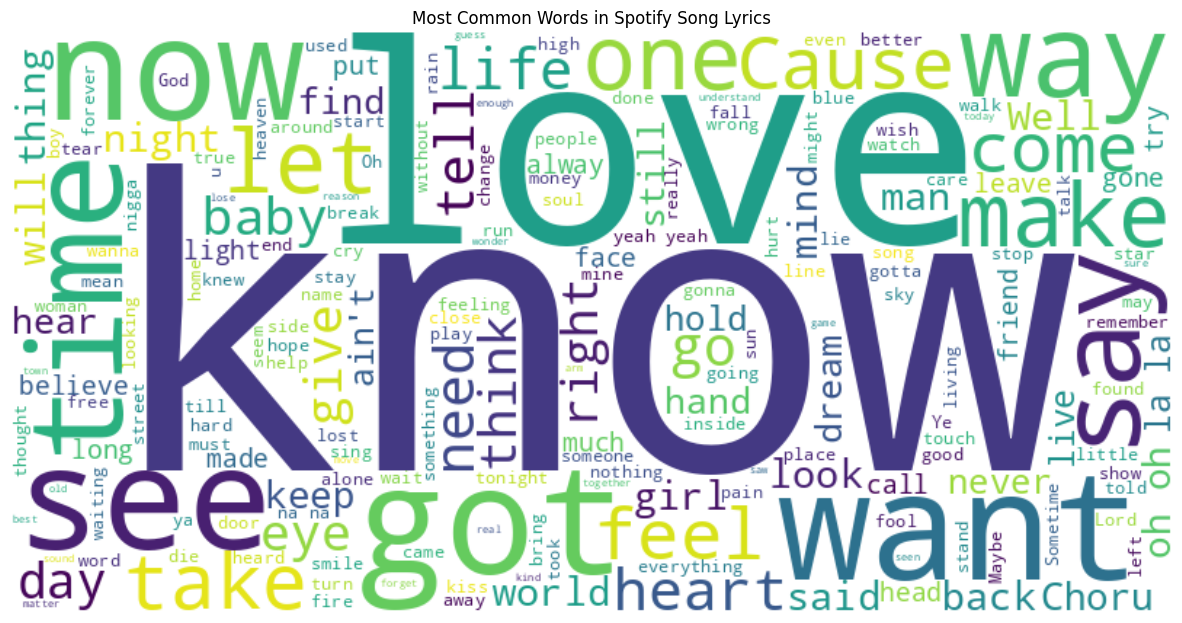

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all lyrics
all_words = ' '.join(df['text'].astype(str))

# Create word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

# Display word cloud
plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Spotify Song Lyrics')

plt.show()

In [15]:
# Count sentiments by artist
artist_sentiment = df.groupby(['artist', 'Sentiment']).size().unstack()

artist_sentiment.head()

Sentiment,Negative,Neutral,Positive
artist,,,
'n Sync,17.0,1.0,75.0
ABBA,25.0,1.0,87.0
Ace Of Base,10.0,NaN,64.0
Adam Sandler,22.0,NaN,48.0
Adele,14.0,NaN,40.0


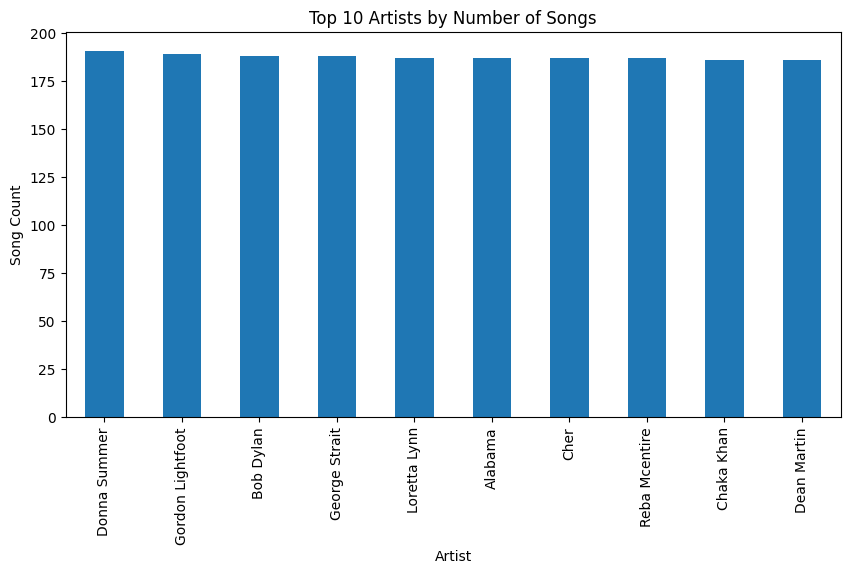

In [16]:
# Top artists with most songs
top_artists = df['artist'].value_counts().head(10)

top_artists.plot(kind='bar', figsize=(10,5))

import matplotlib.pyplot as plt

plt.title('Top 10 Artists by Number of Songs')
plt.xlabel('Artist')
plt.ylabel('Song Count')

plt.show()

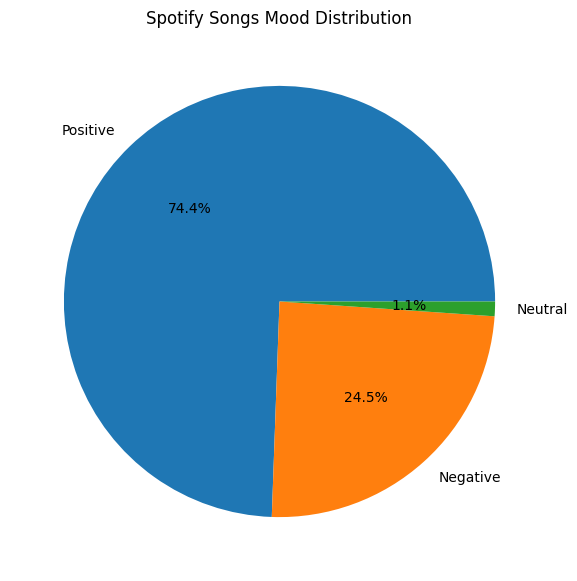

In [17]:
import matplotlib.pyplot as plt

# Sentiment counts
sentiment_counts = df['Sentiment'].value_counts()

# Pie chart
plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title('Spotify Songs Mood Distribution')

plt.show()

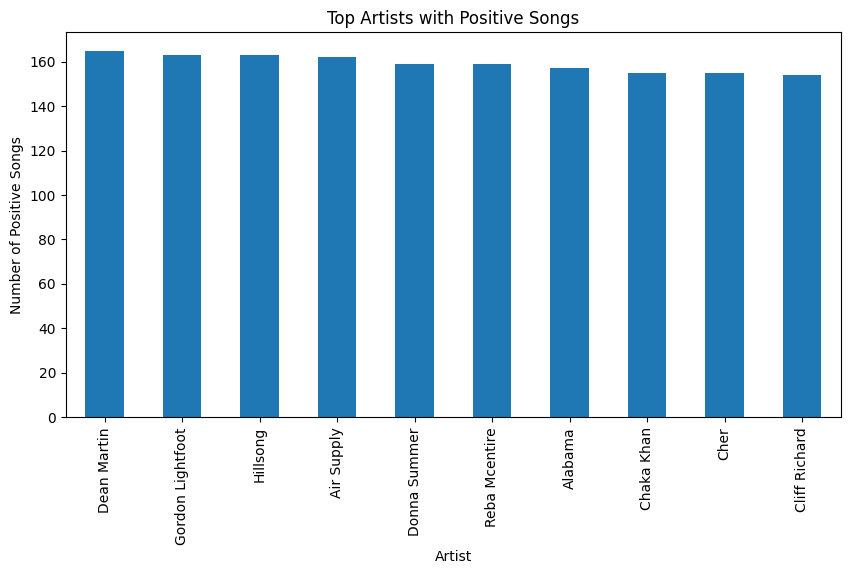

In [18]:
# Top 10 positive artists
positive_artists = df[df['Sentiment'] == 'Positive']['artist'].value_counts().head(10)

plt.figure(figsize=(10,5))

positive_artists.plot(kind='bar')

plt.title('Top Artists with Positive Songs')
plt.xlabel('Artist')
plt.ylabel('Number of Positive Songs')

plt.show()

In [19]:
!pip install spotipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.8/409.8 kB 9.7 MB/s eta 0:00:00


In [20]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

In [21]:
!pip install nrclex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.3 MB/s eta 0:00:00


In [24]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [28]:
# Simple emotion detection using keywords

def detect_emotion(text):
    text = str(text).lower()

    happy_words = ['love', 'happy', 'joy', 'smile', 'fun']
    sad_words = ['cry', 'sad', 'pain', 'alone', 'hurt']
    angry_words = ['hate', 'anger', 'mad', 'fight', 'rage']

    happy_score = sum(word in text for word in happy_words)
    sad_score = sum(word in text for word in sad_words)
    angry_score = sum(word in text for word in angry_words)

    if happy_score > sad_score and happy_score > angry_score:
        return 'Happy'
    elif sad_score > happy_score and sad_score > angry_score:
        return 'Sad'
    elif angry_score > happy_score and angry_score > sad_score:
        return 'Angry'
    else:
        return 'Neutral'

# Create Emotion column
df['Emotion'] = df['text'].apply(detect_emotion)

# Check results
df[['song', 'artist', 'Emotion']].head()

,song,artist,Emotion
0,Ahe's My Kind Of Girl,ABBA,Happy
1,"Andante, Andante",ABBA,Neutral
2,As Good As New,ABBA,Happy
3,Bang,ABBA,Happy
4,Bang-A-Boomerang,ABBA,Happy


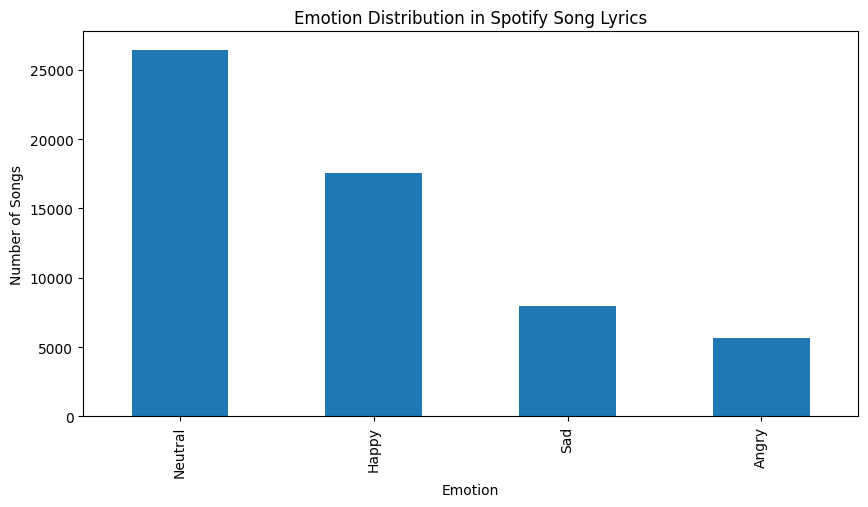

In [29]:
import matplotlib.pyplot as plt

# Count emotions
emotion_counts = df['Emotion'].value_counts()

# Plot graph
plt.figure(figsize=(10,5))

emotion_counts.plot(kind='bar')

plt.title('Emotion Distribution in Spotify Song Lyrics')
plt.xlabel('Emotion')
plt.ylabel('Number of Songs')

plt.show()

In [30]:
# Top artists by number of songs
top_artists = df['artist'].value_counts().head(5).index

# Filter dataset
artist_df = df[df['artist'].isin(top_artists)]

# Emotion count by artist
emotion_artist = artist_df.groupby(['artist', 'Emotion']).size().unstack(fill_value=0)

emotion_artist

Emotion,Angry,Happy,Neutral,Sad
artist,,,,
Bob Dylan,19,52,97,20
Donna Summer,11,71,81,28
George Strait,13,75,66,34
Gordon Lightfoot,12,75,83,19
Loretta Lynn,3,66,86,32


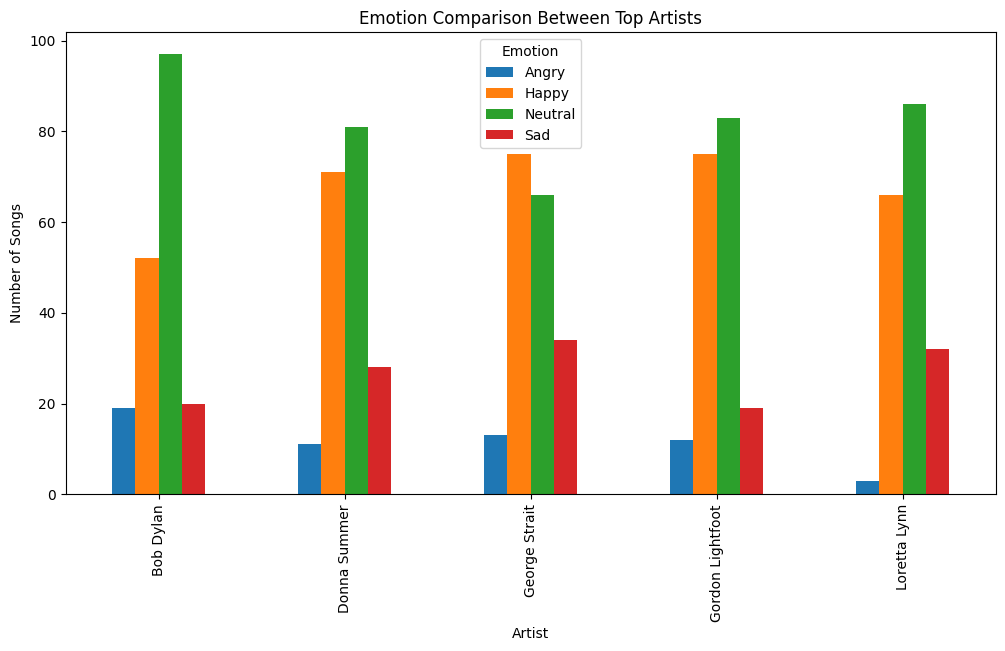

In [31]:
emotion_artist.plot(kind='bar', figsize=(12,6))

import matplotlib.pyplot as plt

plt.title('Emotion Comparison Between Top Artists')
plt.xlabel('Artist')
plt.ylabel('Number of Songs')

plt.show()

In [32]:
# Create pseudo year column
df = df.reset_index()

df['Year'] = (df.index % 20) + 2000

df[['song', 'Year']].head()

,song,Year
0,Ahe's My Kind Of Girl,2000
1,"Andante, Andante",2001
2,As Good As New,2002
3,Bang,2003
4,Bang-A-Boomerang,2004


In [33]:
# Count sentiments by year
yearly_sentiment = df.groupby(['Year', 'Sentiment']).size().unstack(fill_value=0)

yearly_sentiment.head()

Sentiment,Negative,Neutral,Positive
Year,,,
2000,686,38,2159
2001,734,37,2112
2002,707,34,2142
2003,696,32,2155
2004,697,28,2158


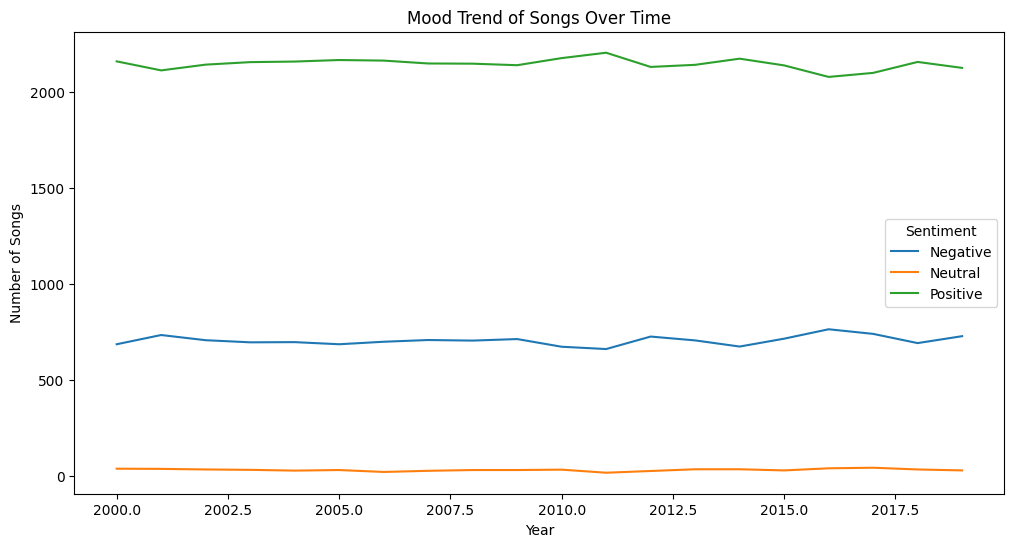

In [34]:
import matplotlib.pyplot as plt

yearly_sentiment.plot(figsize=(12,6))

plt.title('Mood Trend of Songs Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Songs')

plt.show()